# Housing Data
- Simple dataset to create a regression, a bit of testing, and analyzing results.
- Removal of obviously erroneus data points (too high price or house not really existing).
- Create different model for general analysis of the dataset.
- Incorporate categorical data and create a better model.

In [77]:
import pandas as pd
from sklearn import linear_model
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [27]:
housing_df = pd.read_csv('data/housing.csv')
housing_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [28]:
housing_df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [29]:
housing_df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

array([[<Axes: title={'center': 'price'}>]], dtype=object)

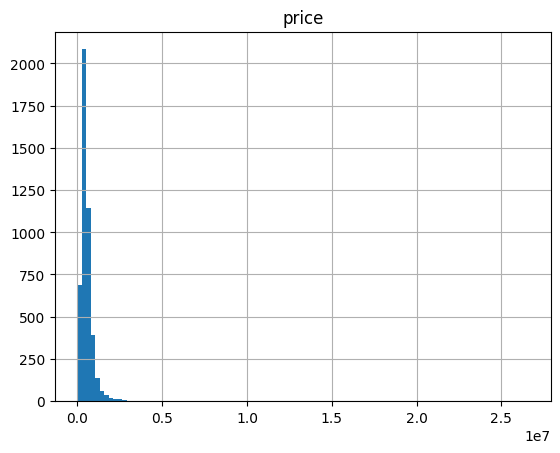

In [30]:
# Make some plots of a few features against target as well as histogram plots of the features.

housing_df.hist('price', bins=100) # Super skewed distro, which is not suprising

array([[<Axes: title={'center': 'bedrooms'}>]], dtype=object)

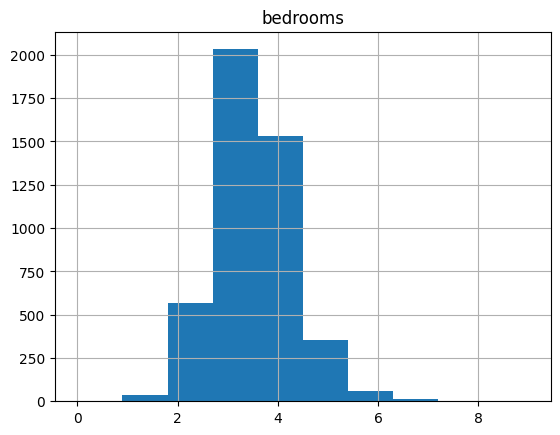

In [31]:
housing_df.hist('bedrooms')

array([[<Axes: title={'center': 'bathrooms'}>]], dtype=object)

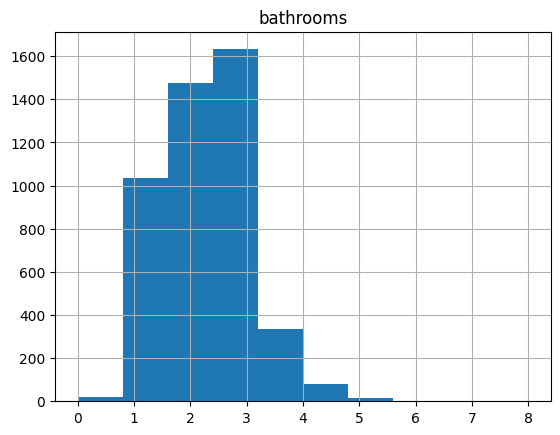

In [32]:
housing_df.hist('bathrooms')

array([[<Axes: title={'center': 'sqft_living'}>]], dtype=object)

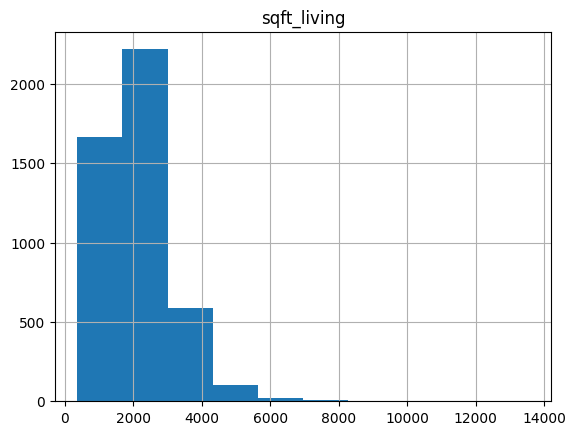

In [33]:
housing_df.hist('sqft_living')

array([[<Axes: title={'center': 'sqft_lot'}>]], dtype=object)

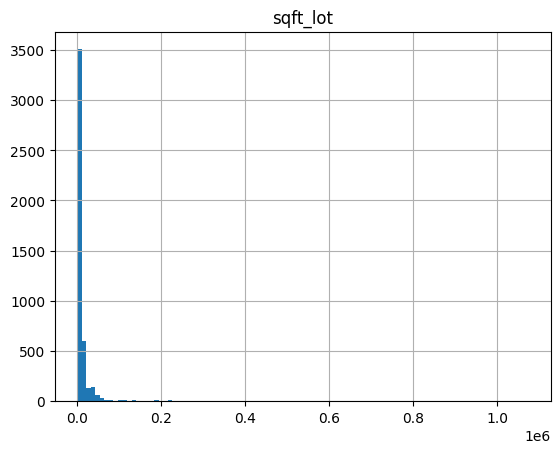

In [34]:
housing_df.hist('sqft_lot', bins=100)

<Axes: xlabel='sqft_living', ylabel='price'>

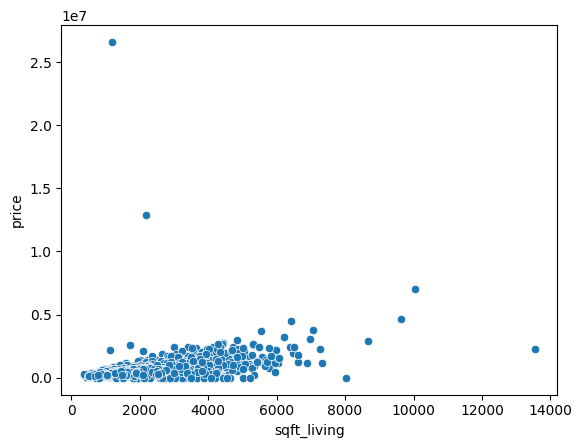

In [35]:
sns.scatterplot(housing_df, y='price', x='sqft_living')

In [ ]:
"""Split the data for cross-validation
Ok, what do I actually want to do with this data?  What do I want to try?

0).  Remove obvious erroneous points.

1).  Let's do a simple cross validation (K-fold) with a holdout test set.

2).  Let's also do a little bit of fit analysis on the model.

3).  Let's show the goodness of fit with a figure.

4).  Maybe at the categorical data as well?
    - The most important honestly may just be zip code.  Highly predictive.


"""

In [47]:
# Clean up the data and remove outliers to create a model.

cleaner_df = housing_df[(housing_df['bedrooms']!=0) | (housing_df['bathrooms']!=0)]

real_homes_df = cleaner_df[(cleaner_df.sqft_living>200)]

clean_df = real_homes_df[(real_homes_df.sqft_lot>200) & 
           (real_homes_df.sqft_living<20000) &
           (real_homes_df.price>10000) & 
           (real_homes_df.price/real_homes_df.sqft_living<5000) &
           (real_homes_df.price>80000) &
           (real_homes_df.price/real_homes_df.sqft_lot>1)
           ].reset_index(drop=True)




<Axes: xlabel='sqft_living', ylabel='price'>

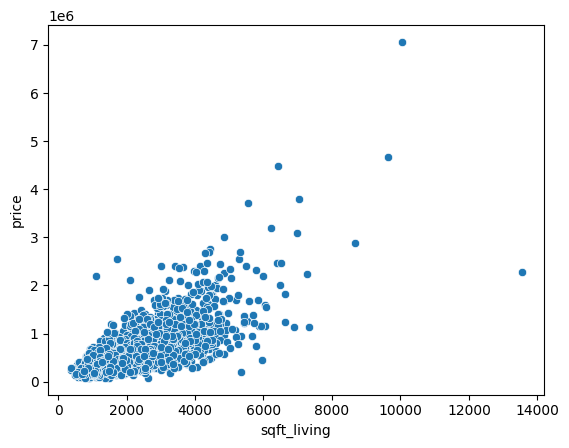

In [50]:
sns.scatterplot(clean_df, y='price', x='sqft_living')

In [72]:
mean_norm_columns = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above','sqft_basement']

categorical_columns = ['statezip']



def z_normalize(column):
    return (column - column.mean())/column.std()



In [ ]:
# Can just make it a most most recent variable, and then standard mean/std normalization afterwords.
# This variable is never null, so it is ok to use.

zip_dummies = pd.get_dummies(clean_df['statezip'], prefix='zip')
clean_df = clean_df.join(pd.get_dummies(clean_df['statezip'], prefix='zip'))

In [69]:
# Split the data somewhat cleanly so that we have what we need here.

train_df, test_df = train_test_split(clean_df,test_size=0.2)

In [73]:
train_df[mean_norm_columns] = train_df[mean_norm_columns].apply(lambda x: z_normalize(x), axis=0)


test_df[mean_norm_columns] = test_df[mean_norm_columns].apply(lambda x: z_normalize(x), axis=0)

In [103]:

from sklearn.linear_model import ElasticNetCV

train_columns = mean_norm_columns + list(zip_dummies.columns)
train_columns = [elem for elem in train_columns if elem!='price']

x_train = train_df[train_columns]
y_train = train_df['price']

x_test = test_df[train_columns]
y_test = test_df['price']

reg_en = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9], cv=5)
reg_en.fit(x_train, y_train)

print(f'Best alpha: {reg_en.alpha_}')
print(f'Best l1_ratio: {reg_en.l1_ratio_}')
print(f'R² on test: {reg_en.score(x_test, y_test):.3f}')
reg_en.fit(x_train, y_train)




Best alpha: 0.0007794271486020211
Best l1_ratio: 0.9
R² on test: 0.746


,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.5, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


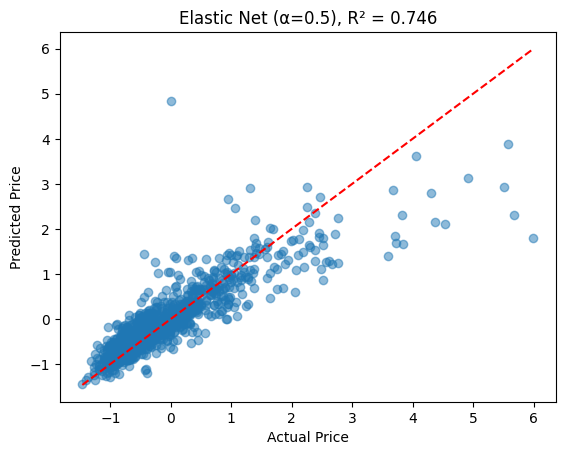

In [105]:
y_pred = reg_en.predict(x_test)
r2 = reg_en.score(x_test, y_test)

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Elastic Net (α=0.5), R² = {r2:.3f}')
plt.show()

In [112]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV R²: {grid_search.best_score_:.3f}')
print(f'Test R²: {grid_search.score(x_test, y_test):.3f}')

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV R²: 0.689
Test R²: 0.687


In [ ]:
# Linear Regression is the best performing